<a href="https://colab.research.google.com/github/abeliyasya/churn_analysis/blob/main/Analisis_Penjualan_KopiNangKau_1305003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kopi NangKau Abeliya Syafa'ah (KNASYA)

## [DATASET.CSV](https://drive.google.com/file/d/1D1hdilPgi6nB8W3HAHnB1Jx87OJBScm8/view?usp=sharing)

In [ ]:
!gdown 1D1hdilPgi6nB8W3HAHnB1Jx87OJBScm8

Downloading...
From: https://drive.google.com/uc?id=1D1hdilPgi6nB8W3HAHnB1Jx87OJBScm8
To: /content/penjualan_kopi_2021_2023.csv
100% 232k/232k [00:00<00:00, 85.2MB/s]


## **Skenario:**

Selamat! Kamu baru saja direkrut sebagai `Data Analyst` di `Kopi NangKau`. Kamu diberikan data penjualan harian dari tahun 2021 hingga 2023. Data ini berisi penjualan berbagai produk minuman dan makanan di toko, tapi terdapat data dobel (duplikat) dan beberapa nilai kosong (missing value).

Tugas kamu adalah membersihkan, mengolah, dan menganalisis data penjualan supaya bisnis bisa terus berkembang.

---

### 💡 Informasi Dasar Harga Produk

| Produk      | Harga Dasar Tahun 2021 (Rp) |
|-------------|----------------------------|
| Espresso    | 22.000                     |
| Latte       | 28.000                     |
| Cappuccino  | 25.000                     |
| Americano   | 21.000                     |
| Croissant   | 18.000                     |
| Donat       | 15.000                     |

- **Harga setiap produk naik 2% setiap tahun**  
  Contoh: Jika harga awal Espresso 22.000 di 2021, maka di 2023:  
  Tahun 2022 → 22.000 × 1.02 = 22.440  
  Tahun 2023 → 22.000 × 1.04 = 22.880 (pembulatan ke bawah karena integer di kode)

---
## TUGAS 1: Eksplorasi Data

1. Baca dataset ke pandas DataFrame.
2. Tampilkan 10 baris pertama.
3. Hitung jumlah baris, kolom, baris duplikat, serta missing value per kolom.
4. Pastikan Kolom Unit_Terjual dan Harga_Per_Unit

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Baca dataset ke pandas data frame
df = pd.read_csv('penjualan_kopi_2021_2023.csv', sep=';')

In [ ]:
# Tampilkan 10 baris pertama
print("10 baris pertama DataFrame:")
print(df.head(10))

# Hitung jumlah baris dan kolom
print(f"\nJumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

# Hitung jumlah baris duplikat
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

# Hitung missing value per kolom
print("\nMissing value per kolom:")
print(df.isnull().sum())
df.info()


10 baris pertama DataFrame:
    Tahun    Bulan  Tanggal      Produk  Unit_Terjual  Harga_Per_Unit
0    2021  Januari        1   Americano          52.0         21000.0
1    2021  Januari        1  Cappuccino          45.0         25000.0
2    2021  Januari        1   Croissant          20.0         18000.0
3    2021  Januari        1       Donat          20.0         15000.0
4    2021  Januari        1    Espresso          43.0         22000.0
5    2021  Januari        1       Latte          38.0         28000.0
6    2021  Januari        2   Americano          44.0         21000.0
7    2021  Januari        2  Cappuccino          36.0         25000.0
8    2021  Januari        2   Croissant          18.0         18000.0
10   2021  Januari        2       Donat          18.0         15000.0

Jumlah baris: 6041
Jumlah kolom: 6
Jumlah baris duplikat: 0

Missing value per kolom:
Tahun             0
Bulan             0
Tanggal           0
Produk            0
Unit_Terjual      0
Harga_Per_Unit 


---

## TUGAS 2: Data Cleaning & Imputasi

1. Untuk baris di mana **Produk kosong tapi Harga_Per_Unit ada**:  
   - Lengkapi nilai Produk dengan cara mencocokkan harga dan tahun pada daftar harga.
2. Untuk baris di mana **Harga_Per_Unit kosong tapi Produk ada**:  
   - Lengkapi Harga_Per_Unit berdasar produk dan tahun (lihat tabel harga & rumus kenaikan).
3. Untuk baris dengan **Produk & Harga_Per_Unit sama-sama kosong**, hapus baris tersebut.
4. Untuk **Unit_Terjual** yang kosong, langsung hapus baris.
5. Pastikan tidak ada nilai negatif di Unit_Terjual.
6. Hapus baris duplikat.

In [ ]:
# TUGAS 2: Data Cleaning & Imputasi

# 1. Menefinisikan harga dasar produk tahun 2021
harga_dasar_2021 = {
    'Espresso': 22000,
    'Latte': 28000,
    'Cappuccino': 25000,
    'Americano': 21000,
    'Croissant': 18000,
    'Donat': 15000
}

# Fungsi untuk mendapatkan harga produk berdasarkan tahun
def get_harga_per_tahun(produk, tahun):
    base_price = harga_dasar_2021.get(produk)
    if base_price is None:
        return None
    if tahun == 2021:
        return base_price
    elif tahun == 2022:
        return round(base_price * 1.02)
    elif tahun == 2023:
        return round(base_price * 1.04)
    return None

# 2. Imputasi Produk ketika Produk kosong tapi Harga_Per_Unit ada
# Periksa baris di mana 'Produk' kosong dan 'Harga_Per_Unit' tidak kosong
for index, row in df[(df['Produk'].isnull()) & (df['Harga_Per_Unit'].notnull())].iterrows():
    tahun = row['Tahun']
    harga_unit = row['Harga_Per_Unit']
    # Cari produk yang cocok dengan harga dan tahun
    for produk, base_price_2021 in harga_dasar_2021.items():
        calculated_price = get_harga_per_tahun(produk, tahun)
        if calculated_price == harga_unit:
            df.loc[index, 'Produk'] = produk
            break

# 3. Imputasi Harga_Per_Unit ketika Harga_Per_Unit kosong tapi Produk ada
# Periksa baris di mana 'Harga_Per_Unit' kosong dan 'Produk' tidak kosong
for index, row in df[(df['Harga_Per_Unit'].isnull()) & (df['Produk'].notnull())].iterrows():
    df.loc[index, 'Harga_Per_Unit'] = get_harga_per_tahun(row['Produk'], row['Tahun'])

# 4. Hapus baris dengan Produk & Harga_Per_Unit sama-sama kosong
df.dropna(subset=['Produk', 'Harga_Per_Unit'], how='all', inplace=True)

# 5. Hapus baris dengan Unit_Terjual kosong
df.dropna(subset=['Unit_Terjual'], inplace=True)

# 6. Pastikan tidak ada nilai negatif di Unit_Terjual
df = df[df['Unit_Terjual'] >= 0]

# 7. Hapus baris duplikat
df.drop_duplicates(inplace=True)

# Tampilkan informasi setelah cleaning untuk verifikasi
print("\nInformasi DataFrame setelah cleaning:")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
print("\nMissing value per kolom setelah cleaning:")
print(df.isnull().sum())


Informasi DataFrame setelah cleaning:
Jumlah baris: 6041
Jumlah kolom: 6
Jumlah baris duplikat: 0

Missing value per kolom setelah cleaning:
Tahun             0
Bulan             0
Tanggal           0
Produk            0
Unit_Terjual      0
Harga_Per_Unit    0
dtype: int64




---


## TUGAS 3: Feature Engineering

1. Buat kolom baru "Pendapatan".
2. Buat kolom "Tanggal_Penjualan" dengan format datetime.

In [ ]:
# TUGAS 3: Feature Engineering

# 1. Buat kolom baru 'Pendapatan'
df['Pendapatan'] = df['Unit_Terjual'] * df['Harga_Per_Unit']

# Mapping bulan Indonesia ke Inggris
bulan_mapping = {
    'Januari': 'January', 'Februari': 'February', 'Maret': 'March', 'April': 'April',
    'Mei': 'May', 'Juni': 'June', 'Juli': 'July', 'Agustus': 'August',
    'September': 'September', 'Oktober': 'October', 'November': 'November', 'Desember': 'December'
}

# Konversi kolom 'Bulan' ke nama bulan dalam bahasa Inggris
df['Bulan'] = df['Bulan'].replace(bulan_mapping)

# 2. Buat kolom 'Tanggal_Penjualan' dengan format datetime
df['Tanggal_Penjualan'] = pd.to_datetime(df['Tahun'].astype(str) + '-' + df['Bulan'] + '-' + df['Tanggal'].astype(str), format='%Y-%B-%d')

# Tampilkan 5 baris pertama dengan kolom baru untuk verifikasi
print("5 baris pertama DataFrame setelah Feature Engineering:")
print(df.head())

# Tampilkan informasi tipe data untuk verifikasi
print("\nInfo DataFrame setelah Feature Engineering:")
df.info()

5 baris pertama DataFrame setelah Feature Engineering:
   Tahun    Bulan  Tanggal      Produk  Unit_Terjual  Harga_Per_Unit  \
0   2021  January        1   Americano          52.0         21000.0   
1   2021  January        1  Cappuccino          45.0         25000.0   
2   2021  January        1   Croissant          20.0         18000.0   
3   2021  January        1       Donat          20.0         15000.0   
4   2021  January        1    Espresso          43.0         22000.0   

   Pendapatan Tanggal_Penjualan  
0   1092000.0        2021-01-01  
1   1125000.0        2021-01-01  
2    360000.0        2021-01-01  
3    300000.0        2021-01-01  
4    946000.0        2021-01-01  

Info DataFrame setelah Feature Engineering:
<class 'pandas.core.frame.DataFrame'>
Index: 6041 entries, 0 to 6598
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Tahun              6041 non-null   int64       



---


## TUGAS 4: Analisis Grup & Visualisasi

1. Hitung total unit & pendapatan per produk.
2. Hitung rata-rata unit terjual per hari tiap produk pada tiap tahun.
3. Temukan produk terlaris per tahun.
4. Buat grafik batang total unit jual per produk (2021 - 2023).


Total Unit dan Pendapatan per Produk:
       Produk  Total_Unit_Terjual  Total_Pendapatan
0   Americano             39265.0      8.407480e+08
1  Cappuccino             39859.0      1.016256e+09
2   Croissant             21360.0      3.921160e+08
3       Donat             22379.0      3.422907e+08
4    Espresso             39504.0      8.865195e+08
5       Latte             39528.0      1.128724e+09

Rata-rata Unit Terjual Per Hari tiap Produk per Tahun:
        Produk  Tahun  Total_Unit_Terjual  Jumlah_Hari_Penjualan  \
0    Americano   2021             13504.0                    337   
1    Americano   2022             12991.0                    340   
2    Americano   2023             12770.0                    329   
3   Cappuccino   2021             13394.0                    340   
4   Cappuccino   2022             13368.0                    337   
5   Cappuccino   2023             13097.0                    327   
6    Croissant   2021              7113.0                    333 

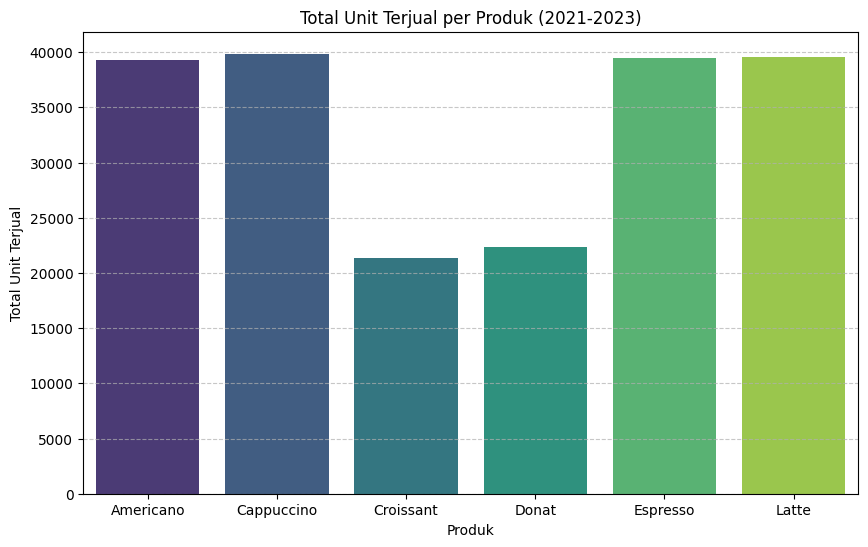

In [ ]:
# TUGAS 4: Analisis Grup & Visualisasi

# 1. Hitung total unit & pendapatan per produk
total_penjualan_produk = df.groupby('Produk').agg(
    Total_Unit_Terjual=('Unit_Terjual', 'sum'),
    Total_Pendapatan=('Pendapatan', 'sum')
).reset_index()
print("\nTotal Unit dan Pendapatan per Produk:")
print(total_penjualan_produk)

# 2. Hitung rata-rata unit terjual per hari tiap produk pada tiap tahun
# Membuat kolom tahun-bulan untuk grouping yang benar
df['Tahun_Bulan'] = df['Tanggal_Penjualan'].dt.to_period('M')

# Menghitung jumlah hari penjualan per produk per tahun
penjualan_harian_produk = df.groupby(['Produk', df['Tanggal_Penjualan'].dt.year]).agg(
    Total_Unit_Terjual=('Unit_Terjual', 'sum'),
    Jumlah_Hari_Penjualan=('Tanggal_Penjualan', lambda x: x.nunique())
).reset_index()
penjualan_harian_produk.rename(columns={'Tanggal_Penjualan': 'Tahun'}, inplace=True)
penjualan_harian_produk['Rata_rata_Unit_Terjual_Per_Hari'] = penjualan_harian_produk['Total_Unit_Terjual'] / penjualan_harian_produk['Jumlah_Hari_Penjualan']

print("\nRata-rata Unit Terjual Per Hari tiap Produk per Tahun:")
print(penjualan_harian_produk)

# 3. Temukan produk terlaris per tahun (berdasarkan Total_Unit_Terjual)
produk_terlaris_per_tahun = penjualan_harian_produk.loc[penjualan_harian_produk.groupby('Tahun')['Total_Unit_Terjual'].idxmax()]
print("\nProduk Terlaris per Tahun:")
print(produk_terlaris_per_tahun[['Tahun', 'Produk', 'Total_Unit_Terjual']])

# 4. Buat grafik batang total unit jual per produk (2021 - 2023)
plt.figure(figsize=(10, 6))
sns.barplot(x='Produk', y='Total_Unit_Terjual', data=total_penjualan_produk, hue='Produk', palette='viridis', legend=False)
plt.title('Total Unit Terjual per Produk (2021-2023)')
plt.xlabel('Produk')
plt.ylabel('Total Unit Terjual')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



---


## TUGAS 5: Rangkuman & Insight

- Tulis ringkasan hasil:
- Sampaikan minimal 2 rekomendasi untuk bisnis.

Ringkasan Hasil

 Latte memiliki total pendapatan tertinggi sebesar Rp 1,128 Miliar (39.528 unit), disusul oleh Cappuccino sebesar Rp 1,016 Miliar (39.859 unit). Walau Cappuccino unggul tipis dari segi kuantitas unit, Latte mengungguli pendapatan karena margin harga jual per unit yang lebih tinggi. Kategori makanan (snack) memberikan kontribusi yang jauh lebih kecil. Croissant hanya mencatatkan pendapatan sebesar Rp 392,1 Juta (21.360 unit) dan Donat sebesar Rp 342,2 Juta (22.379 unit) hampir separuh dari volume penjualan kategori minuman. Penjualan harian produk minuman sangat konsisten dengan rata-rata ~38–40 unit per hari untuk tiap varian (Americano, Cappuccino, Espresso, dan Latte). Sementara produk makanan rata-rata hanya terjual ~20–22 unit per hari. Produk Terlaris per Tahun (Berdasarkan Kuantitas):
1. 2021: Americano (13.504 unit)
2. 2022: Cappuccino (13.368 unit)
3. 2023: Espresso (13.248 unit)

Rekomendasi

StrategiPaket Bundling Kopi + Makanan

Masalah: Volume penjualan makanan (Croissant & Donat) hanya sekitar 50% dari volume penjualan minuman.

Rekomendasi: Buat paket combo pagi atau sore hari (misalnya "Coffee & Bakery Combo" yang menggabungkan Latte/Cappuccino dengan Croissant/Donat) dengan harga promosi menarik. Langkah ini efektif memicu pembelian impulsif produk makanan dan meningkatkan nilai transaksi rata-rata per pelanggan (average order value).

Temuan: Empat varian kopi (Latte, Cappuccino, Espresso, Americano) memberikan kontribusi terbesar dalam stabilitas arus kas harian.

REkomendasi: Buat kartu loyalitas (stamp card) digital atau fisik dengan mekanik "Beli 9 Kopi, Gratis 1 Donat/Croissant". Strategi ini berfungsi ganda: mempertahankan loyalitas penikmat kopi sekaligus memperkenalkan produk makanan kepada pelanggan yang belum pernah mencobanya.

## 🌟 Tugas Opsional / Challenge (Pilihan):



1. **Identifikasi Bulan Tertinggi dan Terendah**
   
   - Temukan bulan dan tahun dengan total penjualan unit tertinggi dan terendah (dalam seluruh periode).
   - Visualisasikan trennya (misal line chart penjualan bulanan).

2. **Analisis Pertumbuhan Penjualan**
   
   - Bandingkan total penjualan (unit terjual maupun pendapatan) antar tahun 2021, 2022, dan 2023.
   - Produk apa yang pertumbuhannya paling tinggi selama 3 tahun?
   - Tampilkan hasilnya dalam bentuk tabel ringkasan pertumbuhan dan/atau visualisasi sederhana.

3. **Simulasi Promo Diskon**
   
   - Simulasikan jika ada diskon 10% untuk produk minuman di bulan-bulan tertentu (misal: Juli & Agustus), dan asumsikan penjualan produk-produk ini naik 15% di bulan promo.
   - Hitung dan bandingkan pendapatan asli vs pendapatan setelah promo.
   - Jelaskan insight-nya, apakah strategi promo ini efektif? (Boleh angka “kasar”, tidak harus persis.)

4. **Deteksi Outlier**
   
   - Temukan hari-hari/tanggal tertentu dimana penjualan produk “melonjak tidak wajar” (misal, tiga kali lipat dari median hariannya).
   - Buat list tanggal tersebut dan sebutkan produk apa saja yang menjadi “outlier”.
   - Akan lebih baik jika langsung ditampilkan dalam bentuk boxplot

5. **Cek Konsistensi Harga**
   
   - Adakah harga produk yang tidak sesuai aturan/rumus kenaikan 2% per tahun? (Cek kolom Harga_Per_Unit)
   - Jika ada data yang tidak konsisten, tampilkan semua kasusnya dan buat analisa ringkas.

---

**Instruksi untuk peserta (opsional):**
Pilih satu atau lebih tugas opsional di atas, lakukan analisis menggunakan pandas, groupby, serta visualisasi yang dikuasai. Laporan insight dan hasil analisis ditulis ringkas namun jelas.

TAMBAHAN

In [ ]:
# 1. Hapus baris duplikat
df_clean = df.drop_duplicates().copy()

# 2. Isi nilai kosong (NaN) pada Unit_Terjual dengan median masing-masing produk
df_clean['Unit_Terjual'] = df_clean.groupby('Produk')['Unit_Terjual'].transform(lambda x: x.fillna(x.median()))

# 3. Hitung total penjualan unit per bulan
penjualan_bulanan = df_clean.groupby(['Tahun', 'Bulan'])['Unit_Terjual'].sum().reset_index()

# 4. Tampilkan bulan tertinggi & terendah
bulan_tertinggi = penjualan_bulanan.loc[penjualan_bulanan['Unit_Terjual'].idxmax()]
bulan_terendah = penjualan_bulanan.loc[penjualan_bulanan['Unit_Terjual'].idxmin()]

print("Bulan Tertinggi:\n", bulan_tertinggi)
print("\nBulan Terendah:\n", bulan_terendah)

Bulan Tertinggi:
 Tahun             2021
Bulan            April
Unit_Terjual    5898.0
Name: 0, dtype: object

Bulan Terendah:
 Tahun               2022
Bulan           November
Unit_Terjual      5274.0
Name: 4, dtype: object


"Sebelum dilakukan analisis agregasi bulanan, dilakukan pembersihan data berupa penghapusan duplikat dan pengisian missing value (NaN) pada kolom Unit_Terjual menggunakan nilai median masing-masing produk. Berdasarkan data yang telah dibersihkan, penjualan unit tertinggi terjadi pada April 2021 (5.898 unit) dan terendah pada Nov 2022 (5.274 unit).

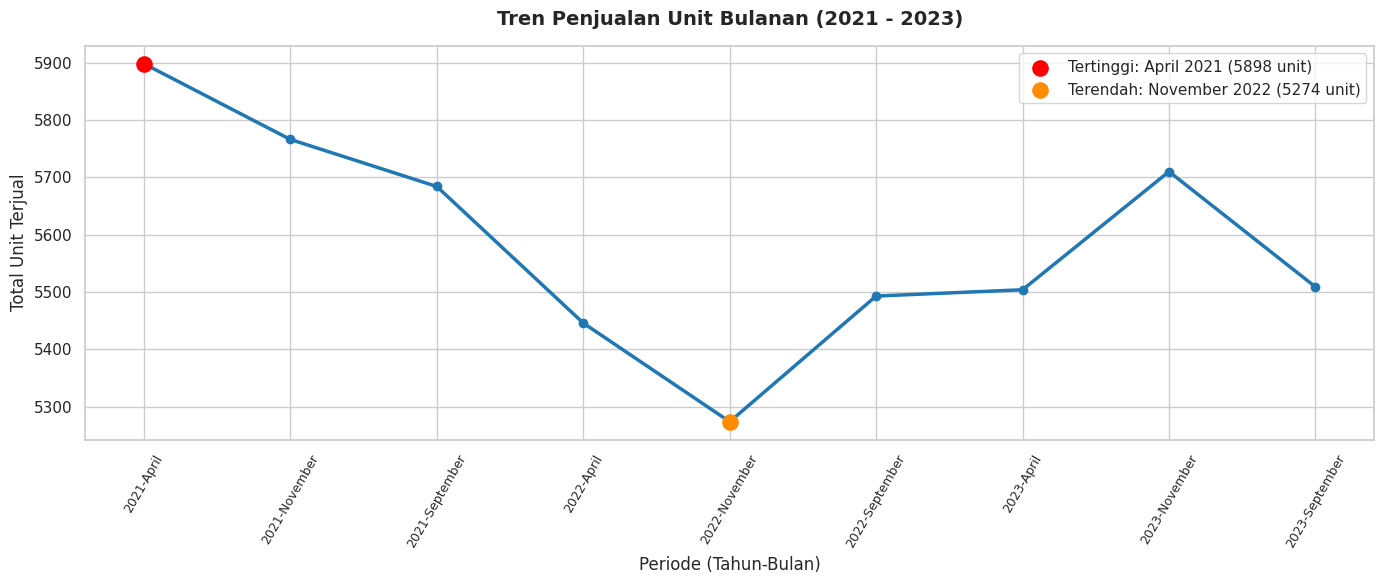

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Buat Line Chart
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Make sure 'Tahun_Bulan' column exists for plotting
# First, combine 'Tahun' and 'Bulan' columns into a single 'Periode' column to represent monthly periods
penjualan_bulanan['Periode'] = penjualan_bulanan['Tahun'].astype(str) + '-' + penjualan_bulanan['Bulan']

plt.plot(penjualan_bulanan['Periode'], penjualan_bulanan['Unit_Terjual'], marker='o', color='#1f77b4', linewidth=2.5)

# Highlight titik tertinggi dan terendah
max_row = penjualan_bulanan.loc[penjualan_bulanan['Unit_Terjual'].idxmax()]
min_row = penjualan_bulanan.loc[penjualan_bulanan['Unit_Terjual'].idxmin()]

plt.scatter(max_row['Periode'], max_row['Unit_Terjual'], color='red', s=120, zorder=5,
            label=f"Tertinggi: {max_row['Bulan']} {max_row['Tahun']} ({max_row['Unit_Terjual']:.0f} unit)")
plt.scatter(min_row['Periode'], min_row['Unit_Terjual'], color='darkorange', s=120, zorder=5,
            label=f"Terendah: {min_row['Bulan']} {min_row['Tahun']} ({min_row['Unit_Terjual']:.0f} unit)")

plt.title('Tren Penjualan Unit Bulanan (2021 - 2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Periode (Tahun-Bulan)', fontsize=12)
plt.ylabel('Total Unit Terjual', fontsize=12)
plt.xticks(rotation=60, fontsize=9)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()



Puncak Penjualan: Penjualan cenderung melesat tinggi pada rentang bulan Maret hingga Mei serta Oktober hingga November di tiap tahunnya.

---

Still hungry of challenge ?
[Try this dataset](https://drive.google.com/file/d/1XQDy8Li_EKcC1QOez1dtjKLguY_MyVOO/view?usp=drive_link)